# Notebook 2 – Exploratory Data Analysis (EDA)
## Airbnb Capstone | Madrid vs Tokyo

**Input:** `airbnb_clean_final.csv` (output of Notebook 1)

### Structure
1. Dataset overview
2. Price distribution & comparison
3. Property & room type analysis
4. Location analysis (neighbourhood)
5. Host behaviour analysis
6. Availability & occupancy patterns
7. Reviews & ratings analysis
8. Correlation analysis
9. Key findings summary

In [9]:
# ── Mount Drive & imports ─────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Consistent colour palette throughout
COLORS     = {"Madrid": "#E63946", "Tokyo": "#457B9D"}
PALETTE    = ["#E63946", "#457B9D"]
DATA_PATH = "/content/drive/Shareddrives/MBD_Capstone Project_KPMG/1. Data/Outputs/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
# ── Load clean dataset ────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH + "airbnb_clean_final.csv")
print(f"Dataset shape: {df.shape}")
print(df["city"].value_counts())

Dataset shape: (41535, 46)
city
Tokyo     23765
Madrid    17770
Name: count, dtype: int64


---
## 1. Dataset Overview

In [11]:
# ── Basic overview ────────────────────────────────────────────────────────────
print("── Shape ──────────────────────────────────")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")

print("\n── Listings per city ──────────────────────")
print(df["city"].value_counts())

print("\n── Numeric summary ────────────────────────")
df.describe().round(2)

── Shape ──────────────────────────────────
Rows: 41,535  |  Columns: 46

── Listings per city ──────────────────────
city
Tokyo     23765
Madrid    17770
Name: count, dtype: int64

── Numeric summary ────────────────────────


,latitude,longitude,accommodates,bedrooms,beds,host_is_superhost,host_response_rate,host_acceptance_rate,host_listings_count,instant_bookable,availability_30,availability_60,availability_90,availability_365,minimum_nights,maximum_nights,number_of_reviews,number_of_reviews_ltm,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,reviews_per_month,price,bathrooms,amenities_count,occupancy_q1,occupancy_q2,occupancy_q3,occupancy_q4,occupancy_autumn,occupancy_spring,occupancy_summer,occupancy_winter,occupancy_rate,occupancy_weekday,occupancy_weekend,total_reviews,days_since_last_review,listing_age_days,reviews_last_6m
count,41535.00,41535.00,41535.00,41535.00,41535.00,41535.00,41535.00,41535.00,41535.00,41535.00,41535.00,41535.00,41535.00,41535.00,41535.00,41535.00,41535.00,41535.00,41535.00,41535.00,41535.00,41535.00,41535.00,41535.00,41535.00,41535.00,41535.00,41535.00,41535.00,41535.00,41535.00,41535.00,41535.00,41535.00,41535.00,41535.00,41535.00,20662.00,20662.00,20662.00,20662.00
mean,37.72,78.37,3.78,1.33,2.40,0.34,0.96,0.92,49.20,0.66,7.71,21.52,41.15,191.92,5.82,405.24,47.08,15.67,4.70,4.71,4.74,4.63,1.80,111.86,1.19,29.89,0.31,0.47,0.60,0.50,0.61,0.43,0.55,0.31,0.46,0.47,0.48,42.64,277.21,1016.60,0.00
std,2.34,70.97,2.37,0.91,1.89,0.47,0.15,0.19,115.09,0.47,7.49,16.26,24.53,104.88,9.75,337.13,86.59,21.58,0.38,0.37,0.31,0.40,1.69,58.88,0.55,11.42,0.37,0.45,0.44,0.29,0.25,0.42,0.45,0.33,0.11,0.29,0.29,71.81,138.73,861.69,0.00
min,35.52,-3.83,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.01,8.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.33,0.00,0.00,1.00,206.00,207.00,0.00
25%,35.70,-3.70,2.00,1.00,1.00,0.00,0.99,0.97,3.00,0.00,2.00,9.00,22.00,105.50,1.00,182.00,2.00,1.00,4.64,4.65,4.67,4.56,0.80,67.41,1.00,24.00,0.00,0.00,0.14,0.28,0.43,0.00,0.00,0.00,0.33,0.21,0.22,7.00,217.00,412.00,0.00
50%,35.74,139.68,3.00,1.00,2.00,0.00,1.00,0.99,11.00,1.00,6.00,18.00,41.00,191.00,2.00,365.00,17.00,8.00,4.79,4.80,4.80,4.71,1.39,99.60,1.00,30.00,0.13,0.29,0.95,0.51,0.63,0.33,0.72,0.19,0.55,0.47,0.49,22.00,230.00,684.00,0.00
75%,40.42,139.74,4.00,2.00,3.00,1.00,1.00,1.00,41.00,1.00,11.00,33.00,60.00,288.00,3.00,365.00,52.00,22.00,4.90,4.92,4.91,4.83,2.29,144.00,1.00,37.00,0.54,1.00,1.00,0.73,0.84,0.84,1.00,0.56,0.55,0.71,0.72,50.00,282.00,1216.00,0.00
max,40.54,139.91,16.00,50.00,50.00,1.00,1.00,1.00,1192.00,1.00,30.00,60.00,90.00,365.00,30.00,20000.00,3705.00,829.00,5.00,5.00,5.00,5.00,51.26,305.00,19.00,92.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.55,1.00,1.00,3705.00,2675.00,5329.00,0.00


In [12]:
# ── Null overview ─────────────────────────────────────────────────────────────
null_pct = (df.isnull().sum() / len(df) * 100).round(1)
null_pct = null_pct[null_pct > 0].sort_values(ascending=False)
print("Columns with nulls:")
print(null_pct)
# Note: ~50% nulls in review-derived columns are expected –
# listings with no reviews have no match in reviews.csv

Columns with nulls:
total_reviews            50.30
days_since_last_review   50.30
listing_age_days         50.30
reviews_last_6m          50.30
dtype: float64


---
## 2. Price Distribution & Comparison

In [13]:
# ── Price summary stats ───────────────────────────────────────────────────────
print(df.groupby("city")["price"].describe().round(2))

          count   mean   std  min   25%    50%    75%    max
city                                                        
Madrid 17770.00 114.60 62.30 8.00 67.00 105.00 150.00 305.00
Tokyo  23765.00 109.81 56.09 9.30 67.57  95.91 139.66 283.98


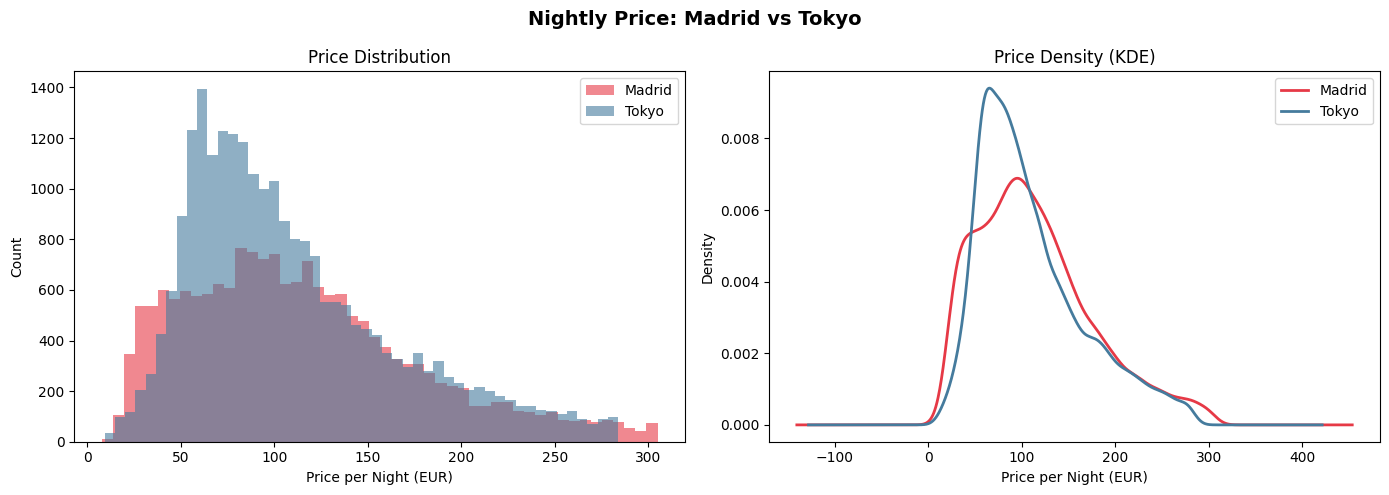

In [14]:
# ── Price distribution: KDE + Histogram ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
for city, color in COLORS.items():
    subset = df[df["city"] == city]["price"]
    axes[0].hist(subset, bins=50, alpha=0.6, color=color, label=city)
axes[0].set_title("Price Distribution")
axes[0].set_xlabel("Price per Night (EUR)")
axes[0].set_ylabel("Count")
axes[0].legend()

# KDE
for city, color in COLORS.items():
    subset = df[df["city"] == city]["price"]
    subset.plot.kde(ax=axes[1], color=color, label=city, linewidth=2)
axes[1].set_title("Price Density (KDE)")
axes[1].set_xlabel("Price per Night (EUR)")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.suptitle("Nightly Price: Madrid vs Tokyo", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

/tmp/ipykernel_8200/3810355467.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="city", y="price", palette=PALETTE, ax=ax)


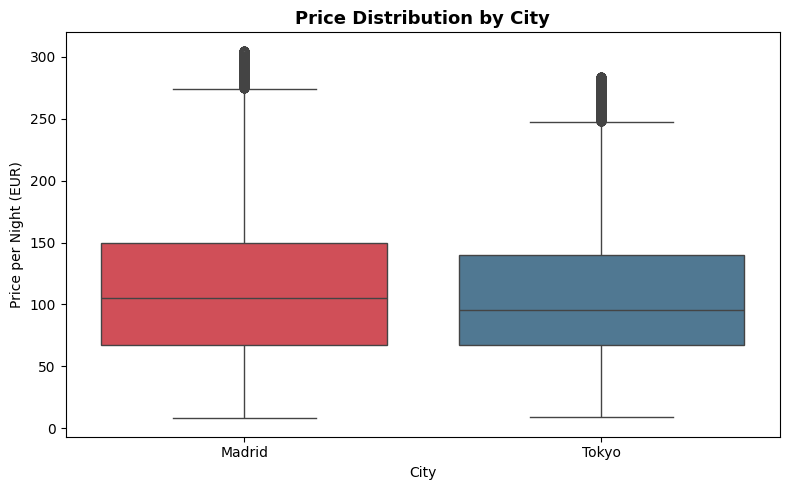


Mann-Whitney U test: stat=220045510, p=0.0000
Interpretation: Significant difference


In [15]:
# ── Boxplot by city ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="city", y="price", palette=PALETTE, ax=ax)
ax.set_title("Price Distribution by City", fontsize=13, fontweight="bold")
ax.set_xlabel("City")
ax.set_ylabel("Price per Night (EUR)")
plt.tight_layout()
plt.show()

# Statistical test: are the price distributions significantly different?
madrid_prices = df[df["city"] == "Madrid"]["price"]
tokyo_prices  = df[df["city"] == "Tokyo"]["price"]
stat, p = stats.mannwhitneyu(madrid_prices, tokyo_prices, alternative="two-sided")
print(f"\nMann-Whitney U test: stat={stat:.0f}, p={p:.4f}")
print("Interpretation:", "Significant difference" if p < 0.05 else "No significant difference")

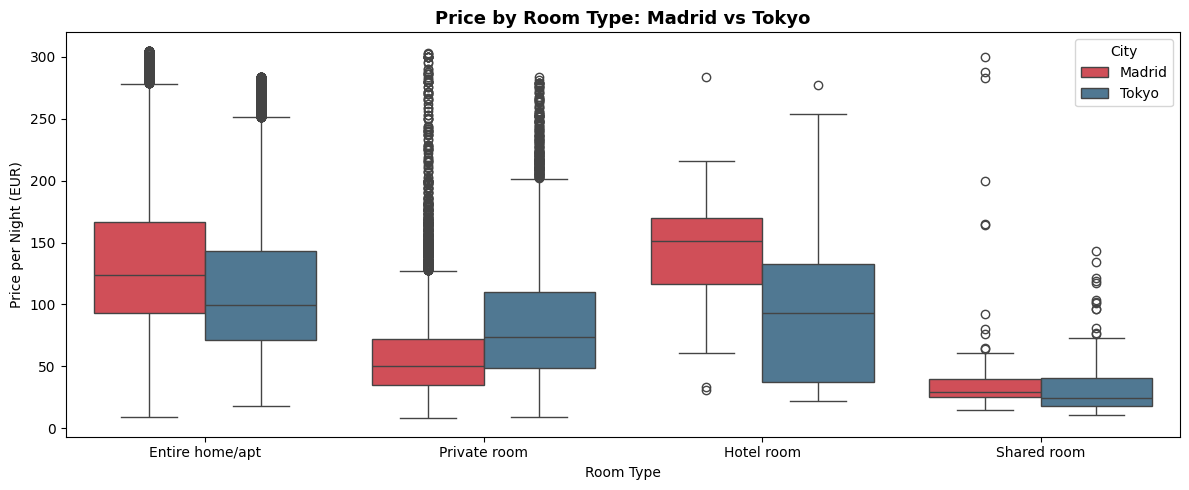

In [16]:
# ── Price by room type ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(
    data=df, x="room_type", y="price", hue="city",
    palette=PALETTE, ax=ax
)
ax.set_title("Price by Room Type: Madrid vs Tokyo", fontsize=13, fontweight="bold")
ax.set_xlabel("Room Type")
ax.set_ylabel("Price per Night (EUR)")
ax.legend(title="City")
plt.tight_layout()
plt.show()

---
## 3. Property & Room Type Analysis

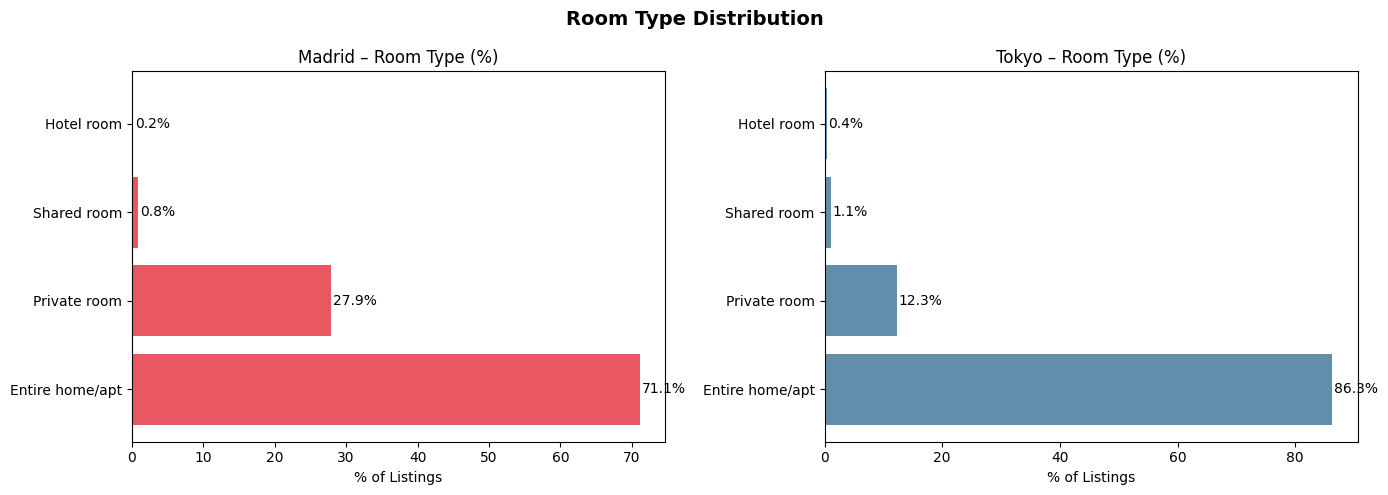

In [17]:
# ── Room type distribution ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, city in zip(axes, ["Madrid", "Tokyo"]):
    counts = (
        df[df["city"] == city]["room_type"]
        .value_counts(normalize=True) * 100
    )
    ax.barh(counts.index, counts.values, color=COLORS[city], alpha=0.85)
    ax.set_title(f"{city} – Room Type (%)")
    ax.set_xlabel("% of Listings")
    for i, v in enumerate(counts.values):
        ax.text(v + 0.3, i, f"{v:.1f}%", va="center")

plt.suptitle("Room Type Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

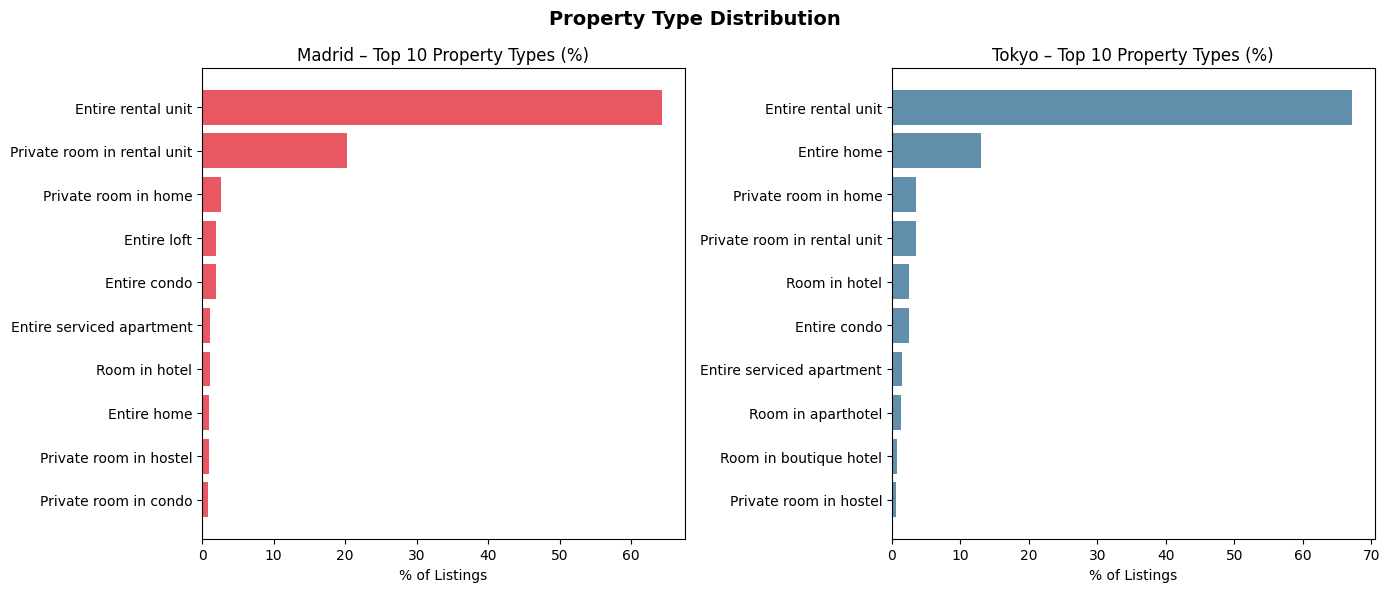

In [18]:
# ── Top property types ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, city in zip(axes, ["Madrid", "Tokyo"]):
    top10 = (
        df[df["city"] == city]["property_type"]
        .value_counts(normalize=True)
        .head(10) * 100
    )
    ax.barh(top10.index[::-1], top10.values[::-1], color=COLORS[city], alpha=0.85)
    ax.set_title(f"{city} – Top 10 Property Types (%)")
    ax.set_xlabel("% of Listings")

plt.suptitle("Property Type Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

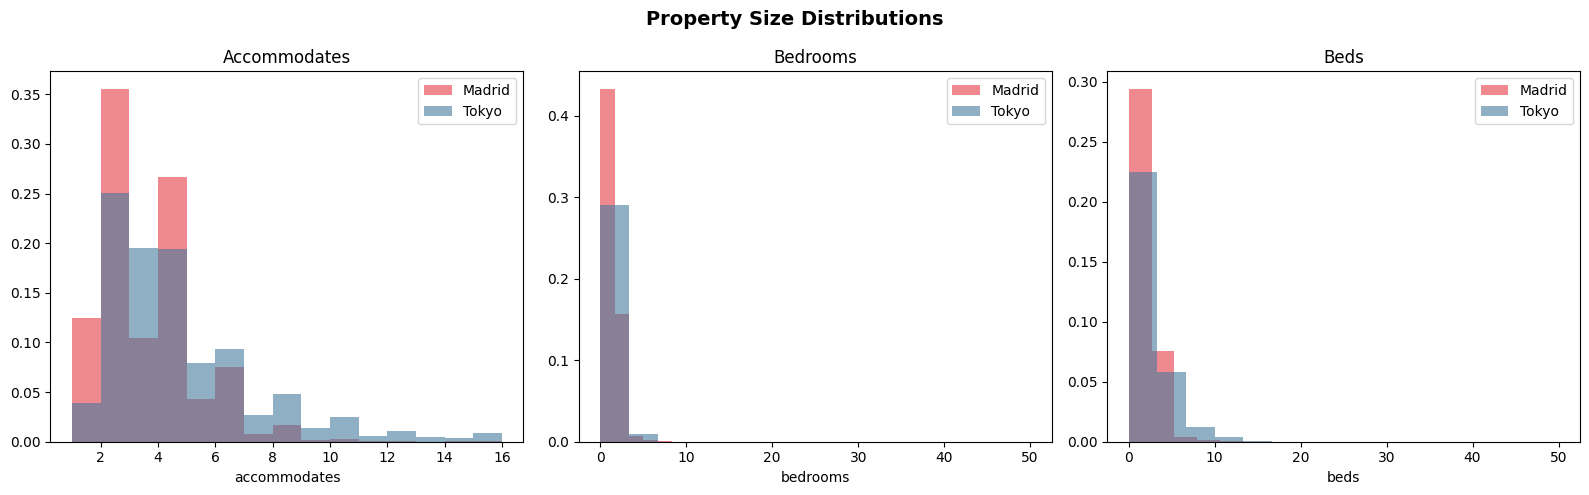

In [19]:
# ── Accommodates, bedrooms, beds distribution ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cols = ["accommodates", "bedrooms", "beds"]

for ax, col in zip(axes, cols):
    for city, color in COLORS.items():
        subset = df[df["city"] == city][col].dropna()
        ax.hist(subset, bins=15, alpha=0.6, color=color, label=city, density=True)
    ax.set_title(col.capitalize())
    ax.set_xlabel(col)
    ax.legend()

plt.suptitle("Property Size Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 4. Location Analysis

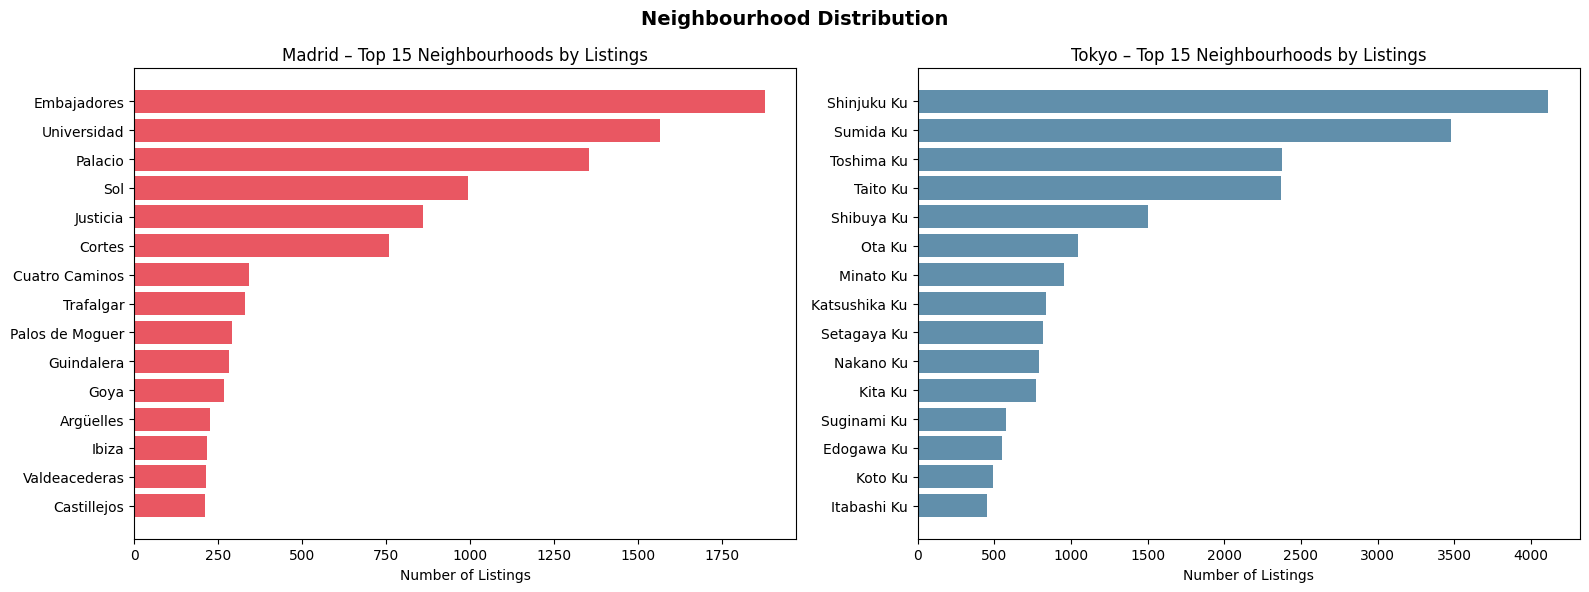

In [20]:
# ── Top neighbourhoods by listing count ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, city in zip(axes, ["Madrid", "Tokyo"]):
    top15 = (
        df[df["city"] == city]["neighbourhood_cleansed"]
        .value_counts()
        .head(15)
    )
    ax.barh(top15.index[::-1], top15.values[::-1], color=COLORS[city], alpha=0.85)
    ax.set_title(f"{city} – Top 15 Neighbourhoods by Listings")
    ax.set_xlabel("Number of Listings")

plt.suptitle("Neighbourhood Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

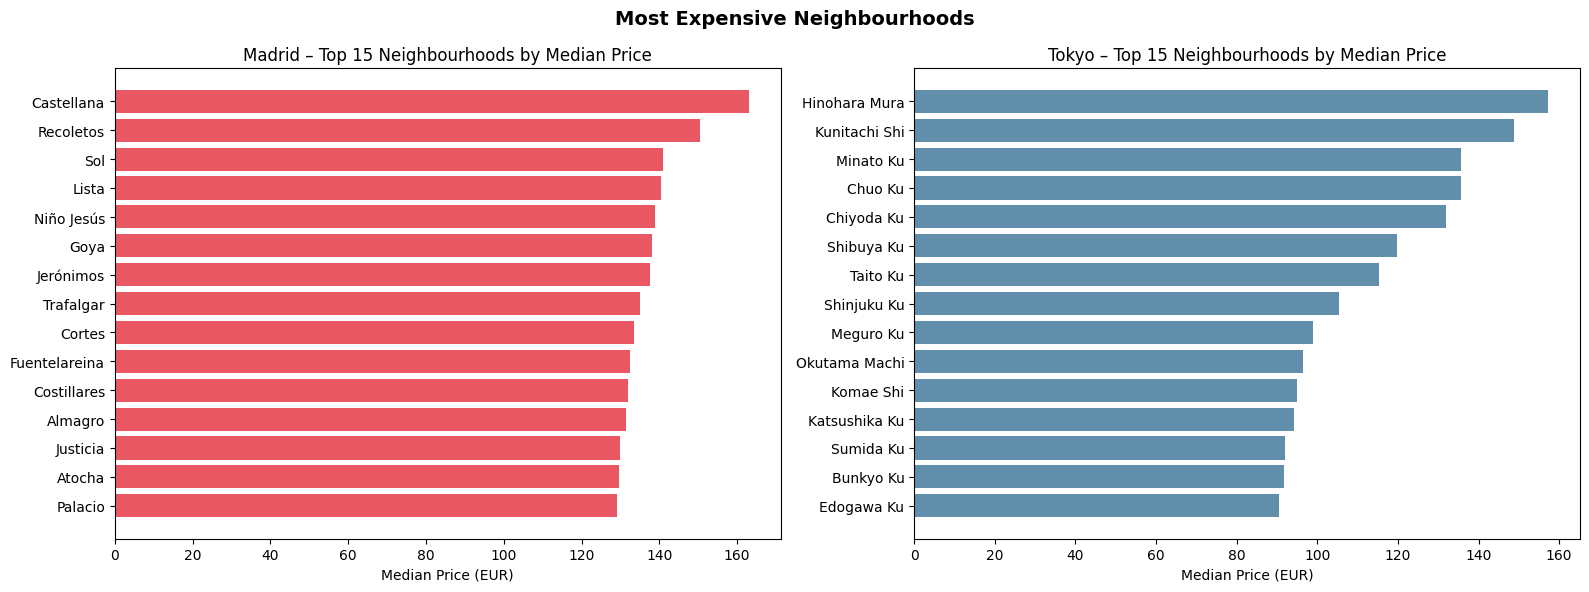

In [21]:
# ── Average price by neighbourhood (top 15) ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, city in zip(axes, ["Madrid", "Tokyo"]):
    top15_price = (
        df[df["city"] == city]
        .groupby("neighbourhood_cleansed")["price"]
        .median()
        .sort_values(ascending=False)
        .head(15)
    )
    ax.barh(top15_price.index[::-1], top15_price.values[::-1], color=COLORS[city], alpha=0.85)
    ax.set_title(f"{city} – Top 15 Neighbourhoods by Median Price")
    ax.set_xlabel("Median Price (EUR)")

plt.suptitle("Most Expensive Neighbourhoods", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

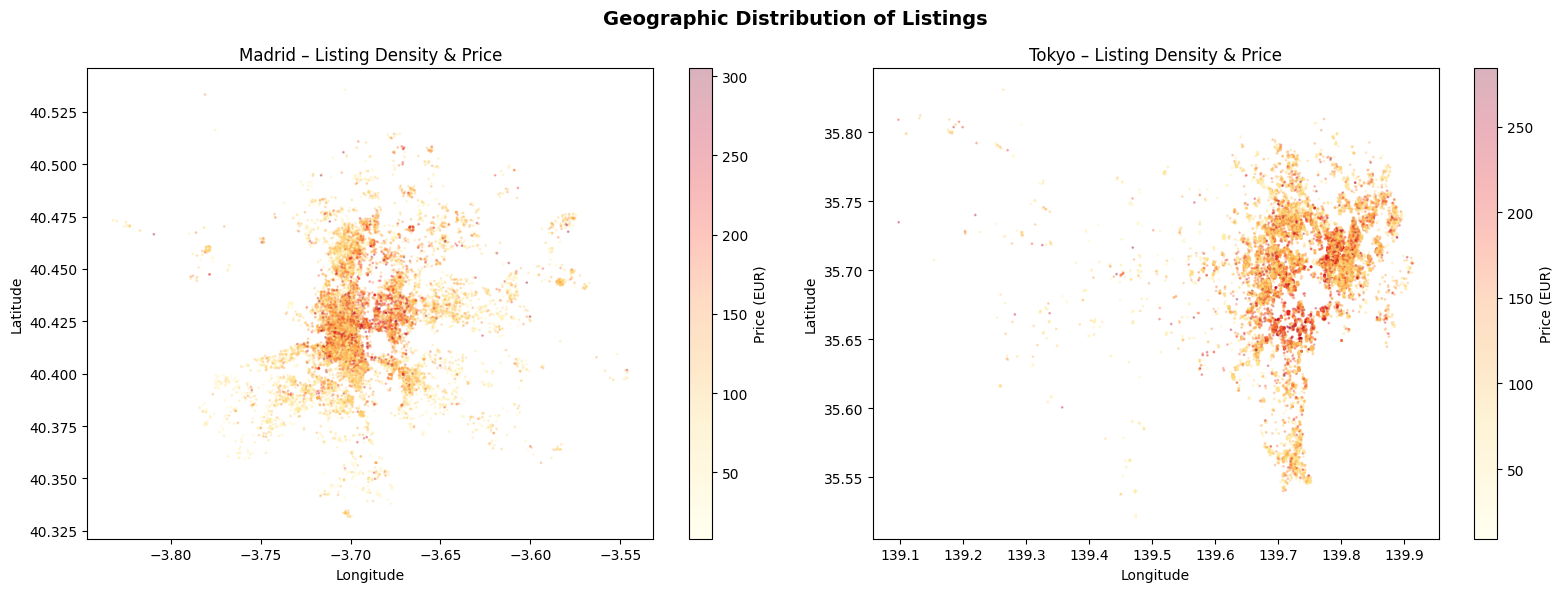

In [22]:
# ── Geographic scatter plot ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, city in zip(axes, ["Madrid", "Tokyo"]):
    subset = df[df["city"] == city]
    sc = ax.scatter(
        subset["longitude"], subset["latitude"],
        c=subset["price"], cmap="YlOrRd",
        alpha=0.3, s=1
    )
    plt.colorbar(sc, ax=ax, label="Price (EUR)")
    ax.set_title(f"{city} – Listing Density & Price")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.suptitle("Geographic Distribution of Listings", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 4.1 Geographic Heatmaps (Madrid vs Tokyo)

In this section, we enhance the location analysis by incorporating geographic data to visualize how Airbnb prices vary across neighbourhoods in Madrid and Tokyo.

First, listing-level data is aggregated at the neighbourhood level, computing key metrics such as median price, average price, listing count, and occupancy rate. We use **median price** instead of average price to reduce the impact of outliers and obtain a more robust representation of typical pricing.

Next, these aggregated metrics are merged with geographic boundary data (GeoJSON files) for each city. This enables the creation of **choropleth maps**, where each neighbourhood is colored according to its price level.

To improve the reliability of the analysis, we apply a **minimum listing threshold** (e.g., 30 listings per neighbourhood). Neighbourhoods with very few listings are excluded, as they can produce misleading price signals due to small sample sizes.

This approach ensures that the maps reflect meaningful market patterns rather than noise. The resulting visualizations help:
- Identify high-value areas within each city  
- Understand how pricing is distributed geographically  
- Provide a stronger foundation for further analysis and modeling  

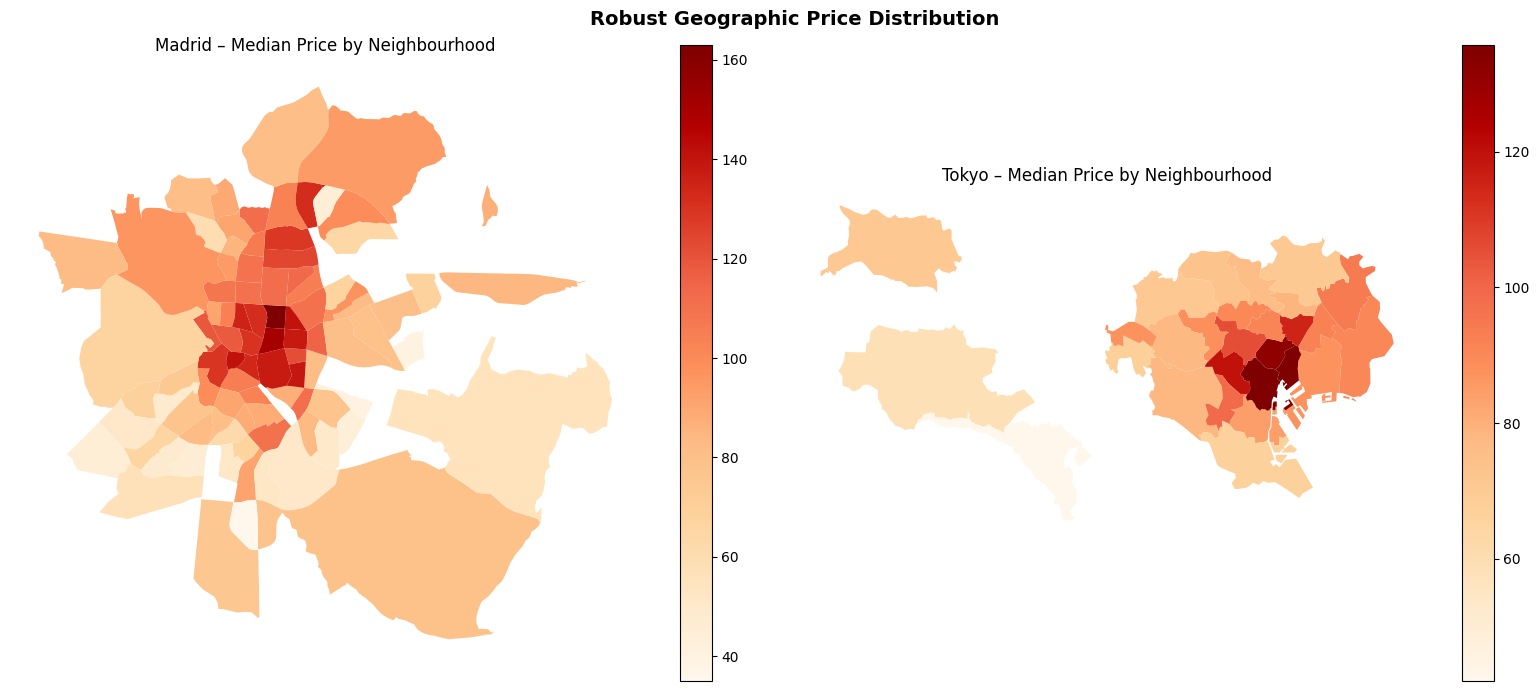

In [23]:
# ── Geographic Heatmaps: Madrid vs Tokyo ─────────────────────────────

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# 1. Paths
geo_path = "/content/drive/Shareddrives/MBD_Capstone Project_KPMG/1. Data/geodata/"

madrid_gdf = gpd.read_file(geo_path + "madrid_neighbourhoods.geojson")
tokyo_gdf  = gpd.read_file(geo_path + "tokyo_neighbourhoods.geojson")

# 2. Aggregate by city + neighbourhood
geo_stats = (
    df.groupby(["city", "neighbourhood_cleansed"])
    .agg(
        median_price=("price", "median"),
        avg_price=("price", "mean"),
        listing_count=("price", "count"),
        occupancy_rate=("occupancy_rate", "mean")
    )
    .reset_index()
)

madrid_stats = geo_stats[geo_stats["city"] == "Madrid"]
tokyo_stats  = geo_stats[geo_stats["city"] == "Tokyo"]

# 3. Merge with geo files
madrid_map = madrid_gdf.merge(
    madrid_stats,
    left_on="neighbourhood",
    right_on="neighbourhood_cleansed",
    how="left"
)

tokyo_map = tokyo_gdf.merge(
    tokyo_stats,
    left_on="neighbourhood",
    right_on="neighbourhood_cleansed",
    how="left"
)

# 4. Filter low-volume neighbourhoods
MIN_LISTINGS = 30

madrid_map_filtered = madrid_map[madrid_map["listing_count"] >= MIN_LISTINGS]
tokyo_map_filtered  = tokyo_map[tokyo_map["listing_count"] >= MIN_LISTINGS]

# 5. Plot median price instead of average price
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

madrid_map_filtered.plot(
    column="median_price",
    cmap="OrRd",
    legend=True,
    ax=axes[0]
)
axes[0].set_title("Madrid – Median Price by Neighbourhood")
axes[0].axis("off")

tokyo_map_filtered.plot(
    column="median_price",
    cmap="OrRd",
    legend=True,
    ax=axes[1]
)
axes[1].set_title("Tokyo – Median Price by Neighbourhood")
axes[1].axis("off")

plt.suptitle("Robust Geographic Price Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [24]:
# Median Price by city
df.groupby("city")["price"].median()

,price
city,
Madrid,105.00
Tokyo,95.91


In [25]:
# Average occupancy by city
df.groupby("city")["occupancy_rate"].mean()

,occupancy_rate
city,
Madrid,0.33
Tokyo,0.55


In [26]:
# ── Top 3 most expensive neighbourhoods (robust) ───────────────────

# Aggregate stats (same as before)
geo_stats = (
    df.groupby(["city", "neighbourhood_cleansed"])
    .agg(
        median_price=("price", "median"),
        listing_count=("price", "count")
    )
    .reset_index()
)

# Apply minimum listing threshold
MIN_LISTINGS = 30

geo_stats_filtered = geo_stats[
    geo_stats["listing_count"] >= MIN_LISTINGS
]

# Get top 3 per city
top3_neighbourhoods = (
    geo_stats_filtered
    .sort_values(["city", "median_price"], ascending=[True, False])
    .groupby("city")
    .head(3)
)

top3_neighbourhoods

,city,neighbourhood_cleansed,median_price,listing_count
30,Madrid,Castellana,163.00,139
100,Madrid,Recoletos,150.50,208
114,Madrid,Sol,141.00,994
158,Tokyo,Minato Ku,135.76,954
135,Tokyo,Chuo Ku,135.67,250
133,Tokyo,Chiyoda Ku,131.83,172


---
## 5. Host Behaviour Analysis

In [27]:
# ── Superhost rate ────────────────────────────────────────────────────────────
superhost_rate = (
    df.groupby("city")["host_is_superhost"]
    .mean() * 100
).round(1)
print("Superhost rate (%):")
print(superhost_rate)

# Price difference: superhost vs non-superhost
print("\nMedian price by superhost status:")
print(df.groupby(["city", "host_is_superhost"])["price"].median().round(2))

Superhost rate (%):
city
Madrid   25.30
Tokyo    41.00
Name: host_is_superhost, dtype: float64

Median price by superhost status:
city    host_is_superhost
Madrid  0.00                105.00
        1.00                108.00
Tokyo   0.00                 87.92
        1.00                107.70
Name: price, dtype: float64


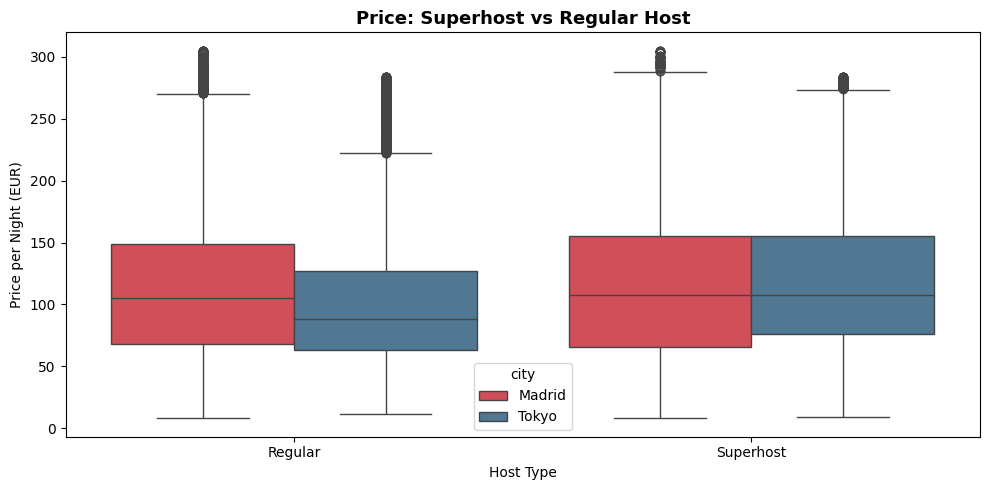

In [28]:
# ── Superhost vs price boxplot ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
df["superhost_label"] = df["host_is_superhost"].map({1: "Superhost", 0: "Regular"})
sns.boxplot(
    data=df, x="superhost_label", y="price",
    hue="city", palette=PALETTE, ax=ax
)
ax.set_title("Price: Superhost vs Regular Host", fontsize=13, fontweight="bold")
ax.set_xlabel("Host Type")
ax.set_ylabel("Price per Night (EUR)")
plt.tight_layout()
plt.show()

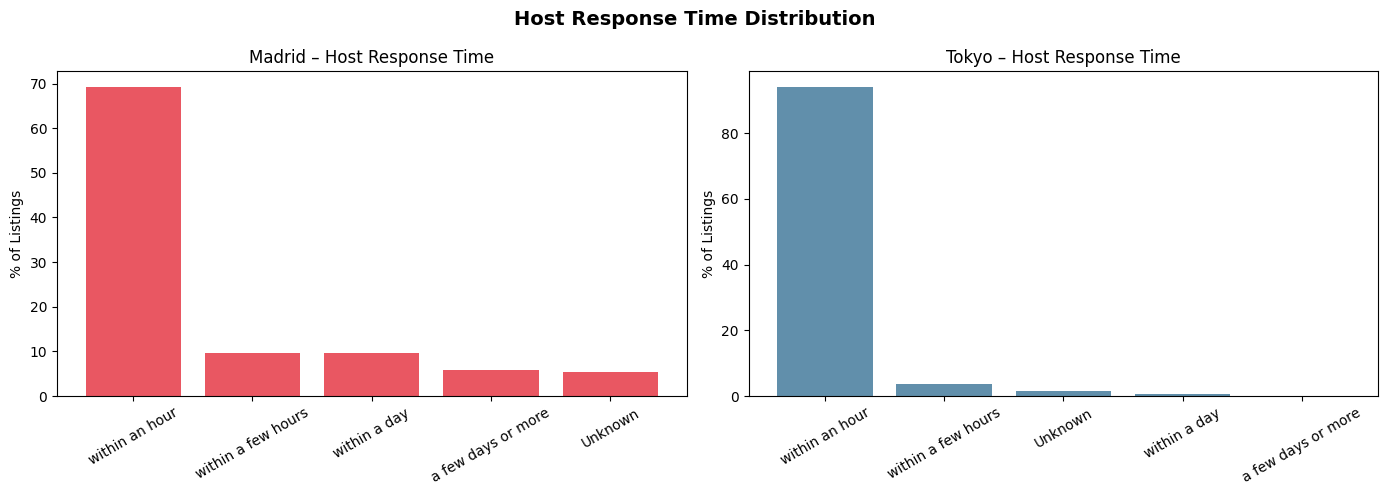

In [29]:
# ── Host response time distribution ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, city in zip(axes, ["Madrid", "Tokyo"]):
    counts = (
        df[df["city"] == city]["host_response_time"]
        .value_counts(normalize=True) * 100
    )
    ax.bar(counts.index, counts.values, color=COLORS[city], alpha=0.85)
    ax.set_title(f"{city} – Host Response Time")
    ax.set_ylabel("% of Listings")
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Host Response Time Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [30]:
# ── Instant bookable rate ─────────────────────────────────────────────────────
instant = (
    df.groupby("city")["instant_bookable"]
    .mean() * 100
).round(1)
print("Instant bookable rate (%):")
print(instant)

print("\nMedian price by instant bookable:")
print(df.groupby(["city", "instant_bookable"])["price"].median().round(2))

Instant bookable rate (%):
city
Madrid   49.20
Tokyo    78.40
Name: instant_bookable, dtype: float64

Median price by instant bookable:
city    instant_bookable
Madrid  0                   87.00
        1                  124.00
Tokyo   0                   95.08
        1                   96.09
Name: price, dtype: float64


---
## 6. Availability & Occupancy Patterns

In [31]:
# ── Overall occupancy rate ────────────────────────────────────────────────────
print("Occupancy rate stats by city:")
print(df.groupby("city")["occupancy_rate"].describe().round(3))

Occupancy rate stats by city:
          count  mean  std  min  25%  50%  75%  max
city                                               
Madrid 17770.00  0.33 0.00 0.33 0.33 0.33 0.33 0.33
Tokyo  23765.00  0.55 0.00 0.55 0.55 0.55 0.55 0.55


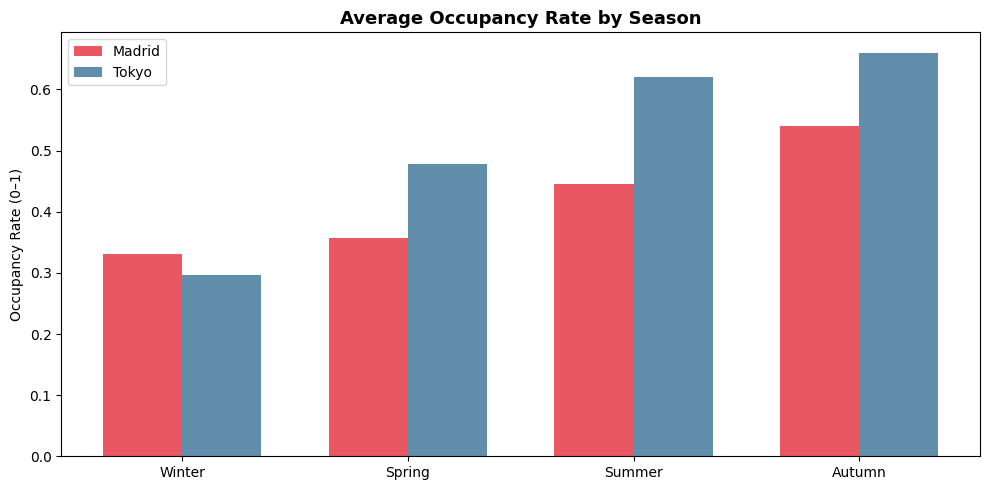

In [32]:
# ── Seasonal occupancy ────────────────────────────────────────────────────────
seasons = ["occupancy_winter", "occupancy_spring", "occupancy_summer", "occupancy_autumn"]
season_labels = ["Winter", "Spring", "Summer", "Autumn"]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(seasons))
width = 0.35

for i, (city, color) in enumerate(COLORS.items()):
    means = df[df["city"] == city][seasons].mean()
    ax.bar(x + i * width, means.values, width, label=city, color=color, alpha=0.85)

ax.set_title("Average Occupancy Rate by Season", fontsize=13, fontweight="bold")
ax.set_xticks(x + width / 2)
ax.set_xticklabels(season_labels)
ax.set_ylabel("Occupancy Rate (0–1)")
ax.legend()
plt.tight_layout()
plt.show()

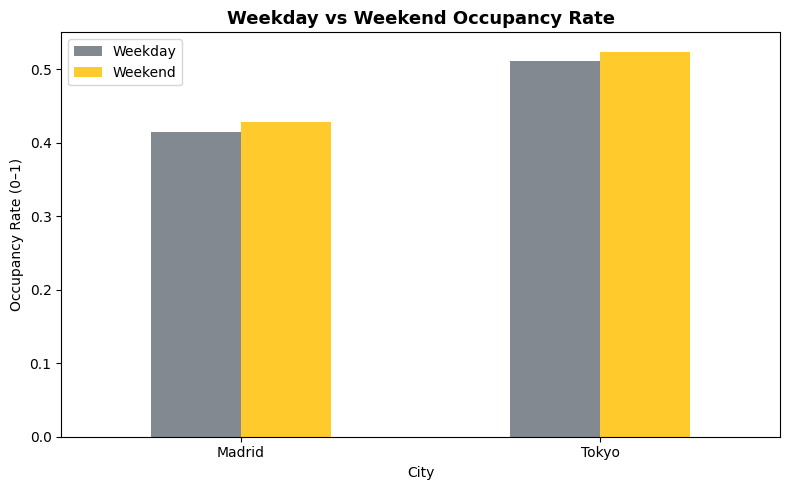

In [33]:
# ── Weekend vs weekday occupancy ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
occ_data = df.groupby("city")[["occupancy_weekday", "occupancy_weekend"]].mean()
occ_data.plot(kind="bar", ax=ax, color=["#6c757d", "#ffc107"], alpha=0.85)
ax.set_title("Weekday vs Weekend Occupancy Rate", fontsize=13, fontweight="bold")
ax.set_ylabel("Occupancy Rate (0–1)")
ax.set_xlabel("City")
ax.tick_params(axis="x", rotation=0)
ax.legend(["Weekday", "Weekend"])
plt.tight_layout()
plt.show()

---
## 7. Reviews & Ratings Analysis

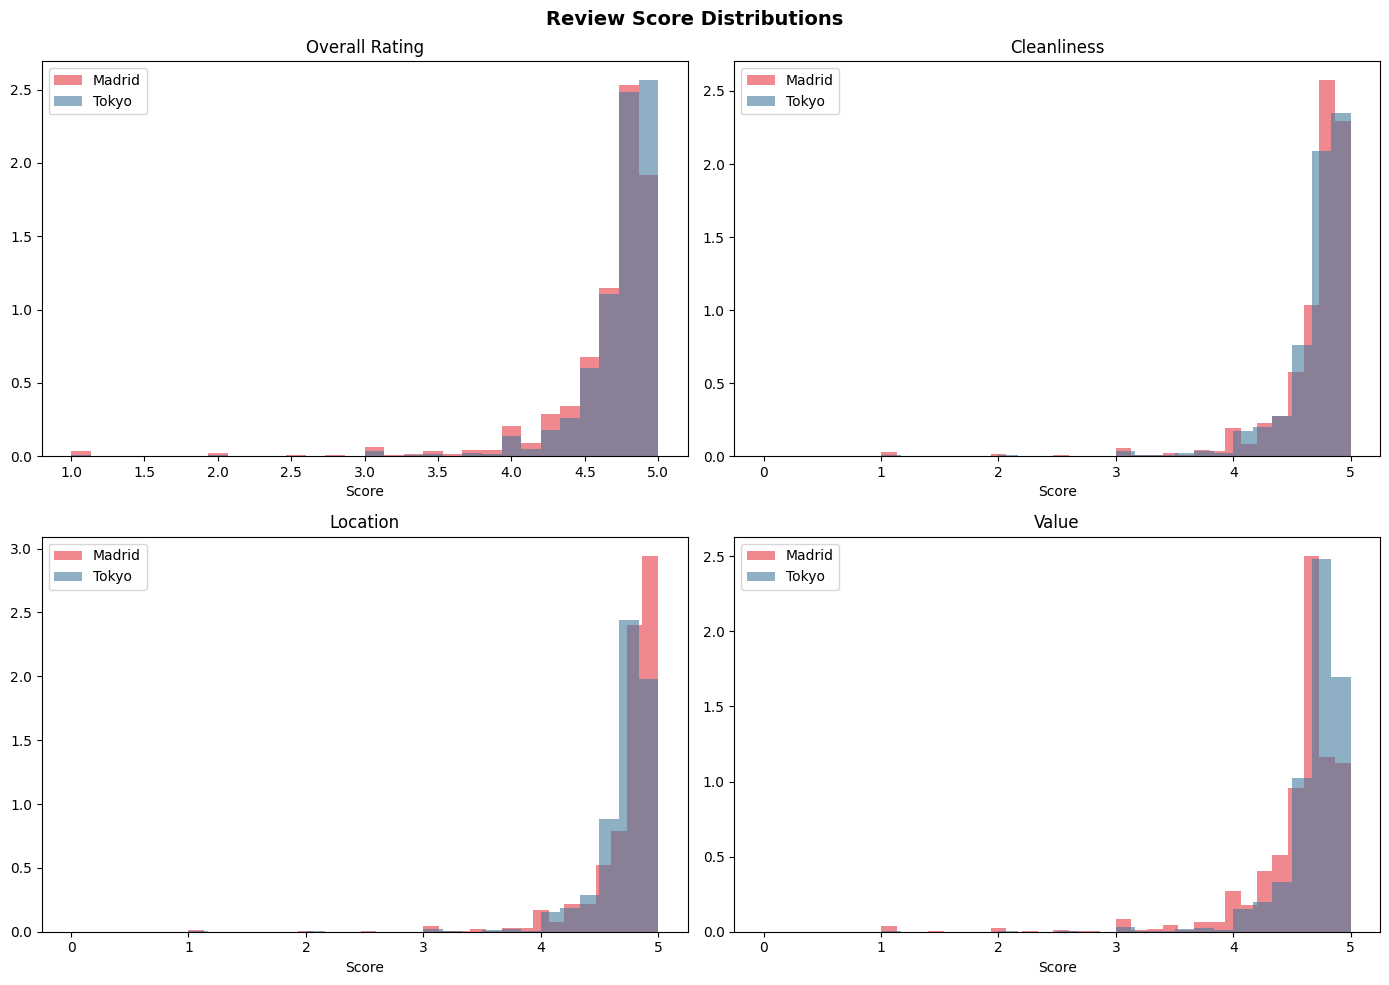


Mean scores by city:
        review_scores_rating  review_scores_cleanliness  \
city                                                      
Madrid                  4.65                       4.69   
Tokyo                   4.74                       4.73   

        review_scores_location  review_scores_value  
city                                                 
Madrid                    4.75                 4.55  
Tokyo                     4.73                 4.69  


In [34]:
# ── Review score distributions ────────────────────────────────────────────────
score_cols = [
    "review_scores_rating",
    "review_scores_cleanliness",
    "review_scores_location",
    "review_scores_value"
]
score_labels = ["Overall Rating", "Cleanliness", "Location", "Value"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col, label in zip(axes, score_cols, score_labels):
    for city, color in COLORS.items():
        subset = df[df["city"] == city][col].dropna()
        ax.hist(subset, bins=30, alpha=0.6, color=color, label=city, density=True)
    ax.set_title(label)
    ax.set_xlabel("Score")
    ax.legend()

plt.suptitle("Review Score Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nMean scores by city:")
print(df.groupby("city")[score_cols].mean().round(2))

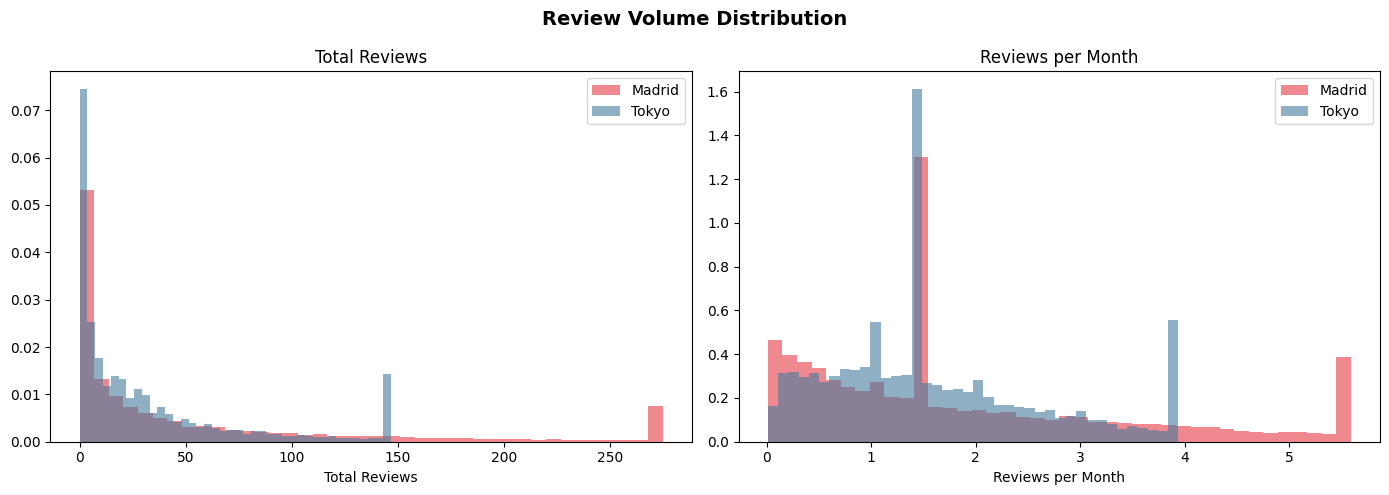

In [35]:
# ── Review volume ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, label in zip(axes,
    ["number_of_reviews", "reviews_per_month"],
    ["Total Reviews", "Reviews per Month"]):
    for city, color in COLORS.items():
        subset = df[df["city"] == city][col].dropna()
        ax.hist(subset.clip(upper=subset.quantile(0.95)),
                bins=40, alpha=0.6, color=color, label=city, density=True)
    ax.set_title(label)
    ax.set_xlabel(label)
    ax.legend()

plt.suptitle("Review Volume Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 8. Correlation Analysis

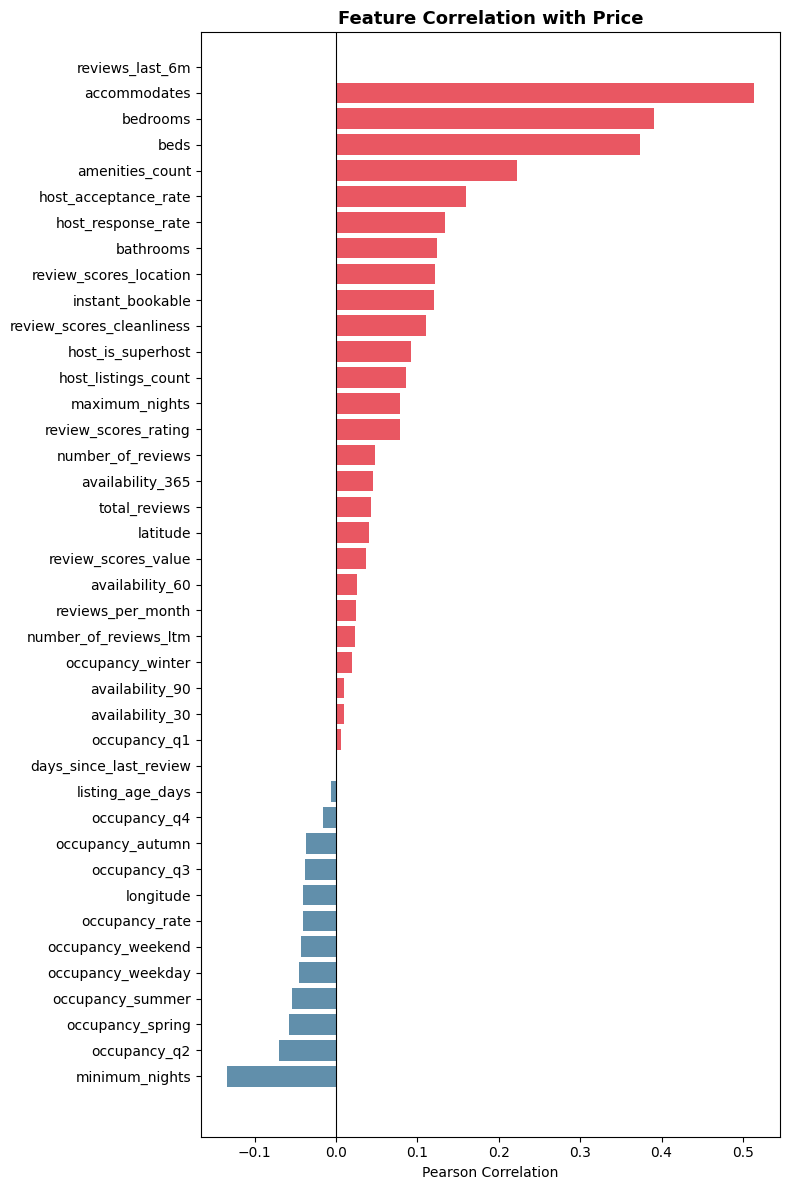

In [36]:
# ── Correlation with price ────────────────────────────────────────────────────
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != "price"]

corr_price = (
    df[numeric_cols + ["price"]]
    .corr()["price"]
    .drop("price")
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8, 12))
colors = ["#E63946" if v > 0 else "#457B9D" for v in corr_price.values]
ax.barh(corr_price.index, corr_price.values, color=colors, alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Feature Correlation with Price", fontsize=13, fontweight="bold")
ax.set_xlabel("Pearson Correlation")
plt.tight_layout()
plt.show()

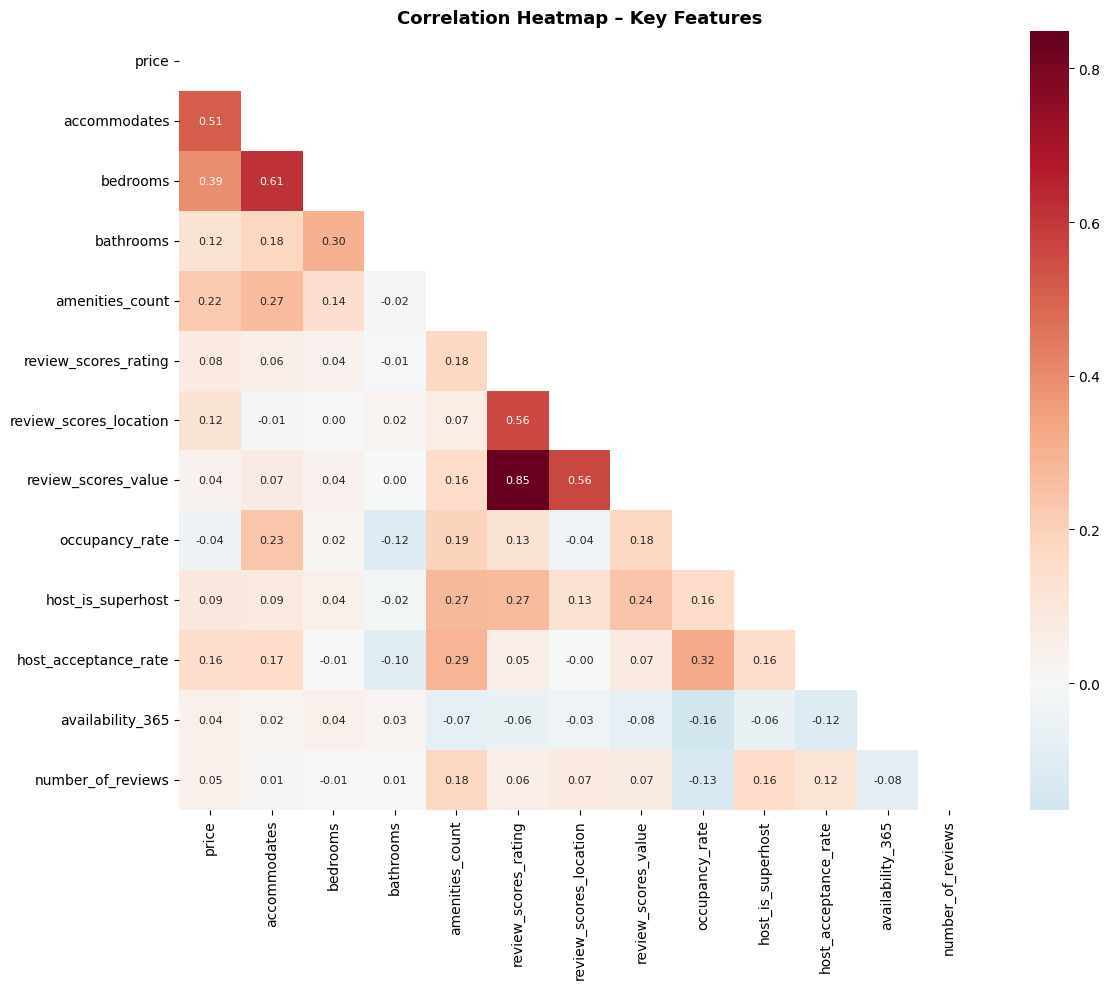

In [37]:
# ── Heatmap of key features ───────────────────────────────────────────────────
key_features = [
    "price", "accommodates", "bedrooms", "bathrooms", "amenities_count",
    "review_scores_rating", "review_scores_location", "review_scores_value",
    "occupancy_rate", "host_is_superhost", "host_acceptance_rate",
    "availability_365", "number_of_reviews"
]
key_features = [c for c in key_features if c in df.columns]

fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = df[key_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, ax=ax,
    annot_kws={"size": 8}
)
ax.set_title("Correlation Heatmap – Key Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

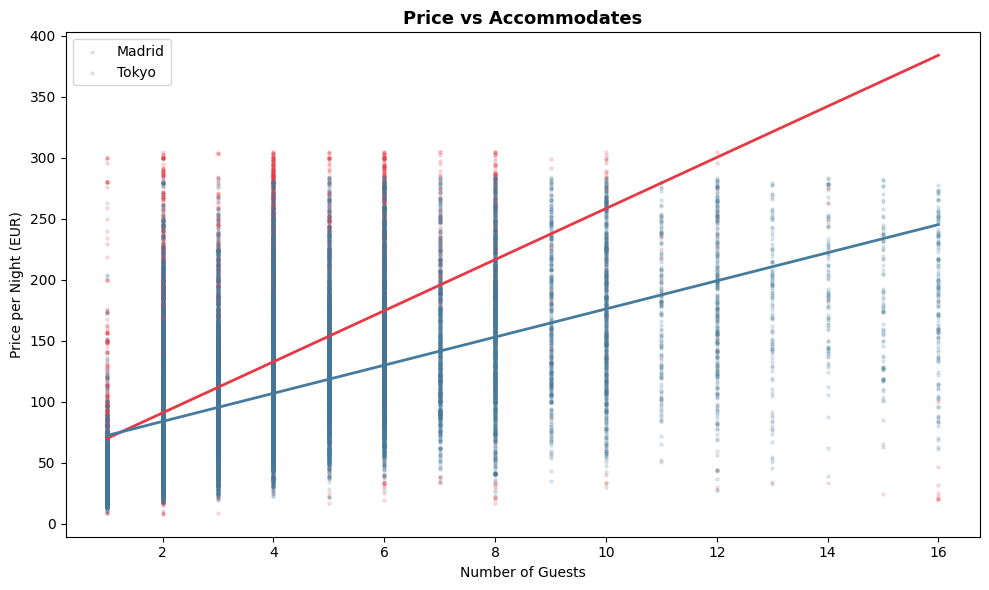

In [38]:
# ── Price vs accommodates scatterplot ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
for city, color in COLORS.items():
    subset = df[df["city"] == city]
    ax.scatter(
        subset["accommodates"], subset["price"],
        alpha=0.15, color=color, s=5, label=city
    )
    # Trend line
    z = np.polyfit(subset["accommodates"], subset["price"], 1)
    p = np.poly1d(z)
    x_range = np.linspace(subset["accommodates"].min(), subset["accommodates"].max(), 100)
    ax.plot(x_range, p(x_range), color=color, linewidth=2)

ax.set_title("Price vs Accommodates", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of Guests")
ax.set_ylabel("Price per Night (EUR)")
ax.legend()
plt.tight_layout()
plt.show()

---
## 9. Key Findings Summary

In [39]:
# ── Auto-generated summary stats ──────────────────────────────────────────────
madrid = df[df["city"] == "Madrid"]
tokyo  = df[df["city"] == "Tokyo"]

print("═" * 55)
print(" KEY FINDINGS: MADRID vs TOKYO")
print("═" * 55)

print(f"\n LISTINGS")
print(f"  Madrid: {len(madrid):,} listings")
print(f"  Tokyo:  {len(tokyo):,} listings")

print(f"\n PRICE (median per night, EUR)")
print(f"  Madrid: €{madrid['price'].median():.0f}")
print(f"  Tokyo:  €{tokyo['price'].median():.0f}")

print(f"\n MOST COMMON ROOM TYPE")
print(f"  Madrid: {madrid['room_type'].mode()[0]}")
print(f"  Tokyo:  {tokyo['room_type'].mode()[0]}")

print(f"\n SUPERHOST RATE")
print(f"  Madrid: {madrid['host_is_superhost'].mean()*100:.1f}%")
print(f"  Tokyo:  {tokyo['host_is_superhost'].mean()*100:.1f}%")

print(f"\n AVERAGE OCCUPANCY RATE")
print(f"  Madrid: {madrid['occupancy_rate'].mean()*100:.1f}%")
print(f"  Tokyo:  {tokyo['occupancy_rate'].mean()*100:.1f}%")

print(f"\n MEAN OVERALL RATING")
print(f"  Madrid: {madrid['review_scores_rating'].mean():.2f}")
print(f"  Tokyo:  {tokyo['review_scores_rating'].mean():.2f}")

print(f"\n  TOP NEIGHBOURHOOD BY LISTINGS")
print(f"  Madrid: {madrid['neighbourhood_cleansed'].mode()[0]}")
print(f"  Tokyo:  {tokyo['neighbourhood_cleansed'].mode()[0]}")
print("═" * 55)

═══════════════════════════════════════════════════════
 KEY FINDINGS: MADRID vs TOKYO
═══════════════════════════════════════════════════════

 LISTINGS
  Madrid: 17,770 listings
  Tokyo:  23,765 listings

 PRICE (median per night, EUR)
  Madrid: €105
  Tokyo:  €96

 MOST COMMON ROOM TYPE
  Madrid: Entire home/apt
  Tokyo:  Entire home/apt

 SUPERHOST RATE
  Madrid: 25.3%
  Tokyo:  41.0%

 AVERAGE OCCUPANCY RATE
  Madrid: 33.2%
  Tokyo:  55.1%

 MEAN OVERALL RATING
  Madrid: 4.65
  Tokyo:  4.74

  TOP NEIGHBOURHOOD BY LISTINGS
  Madrid: Embajadores
  Tokyo:  Shinjuku Ku
═══════════════════════════════════════════════════════
